# エンタープライズブロックチェーン

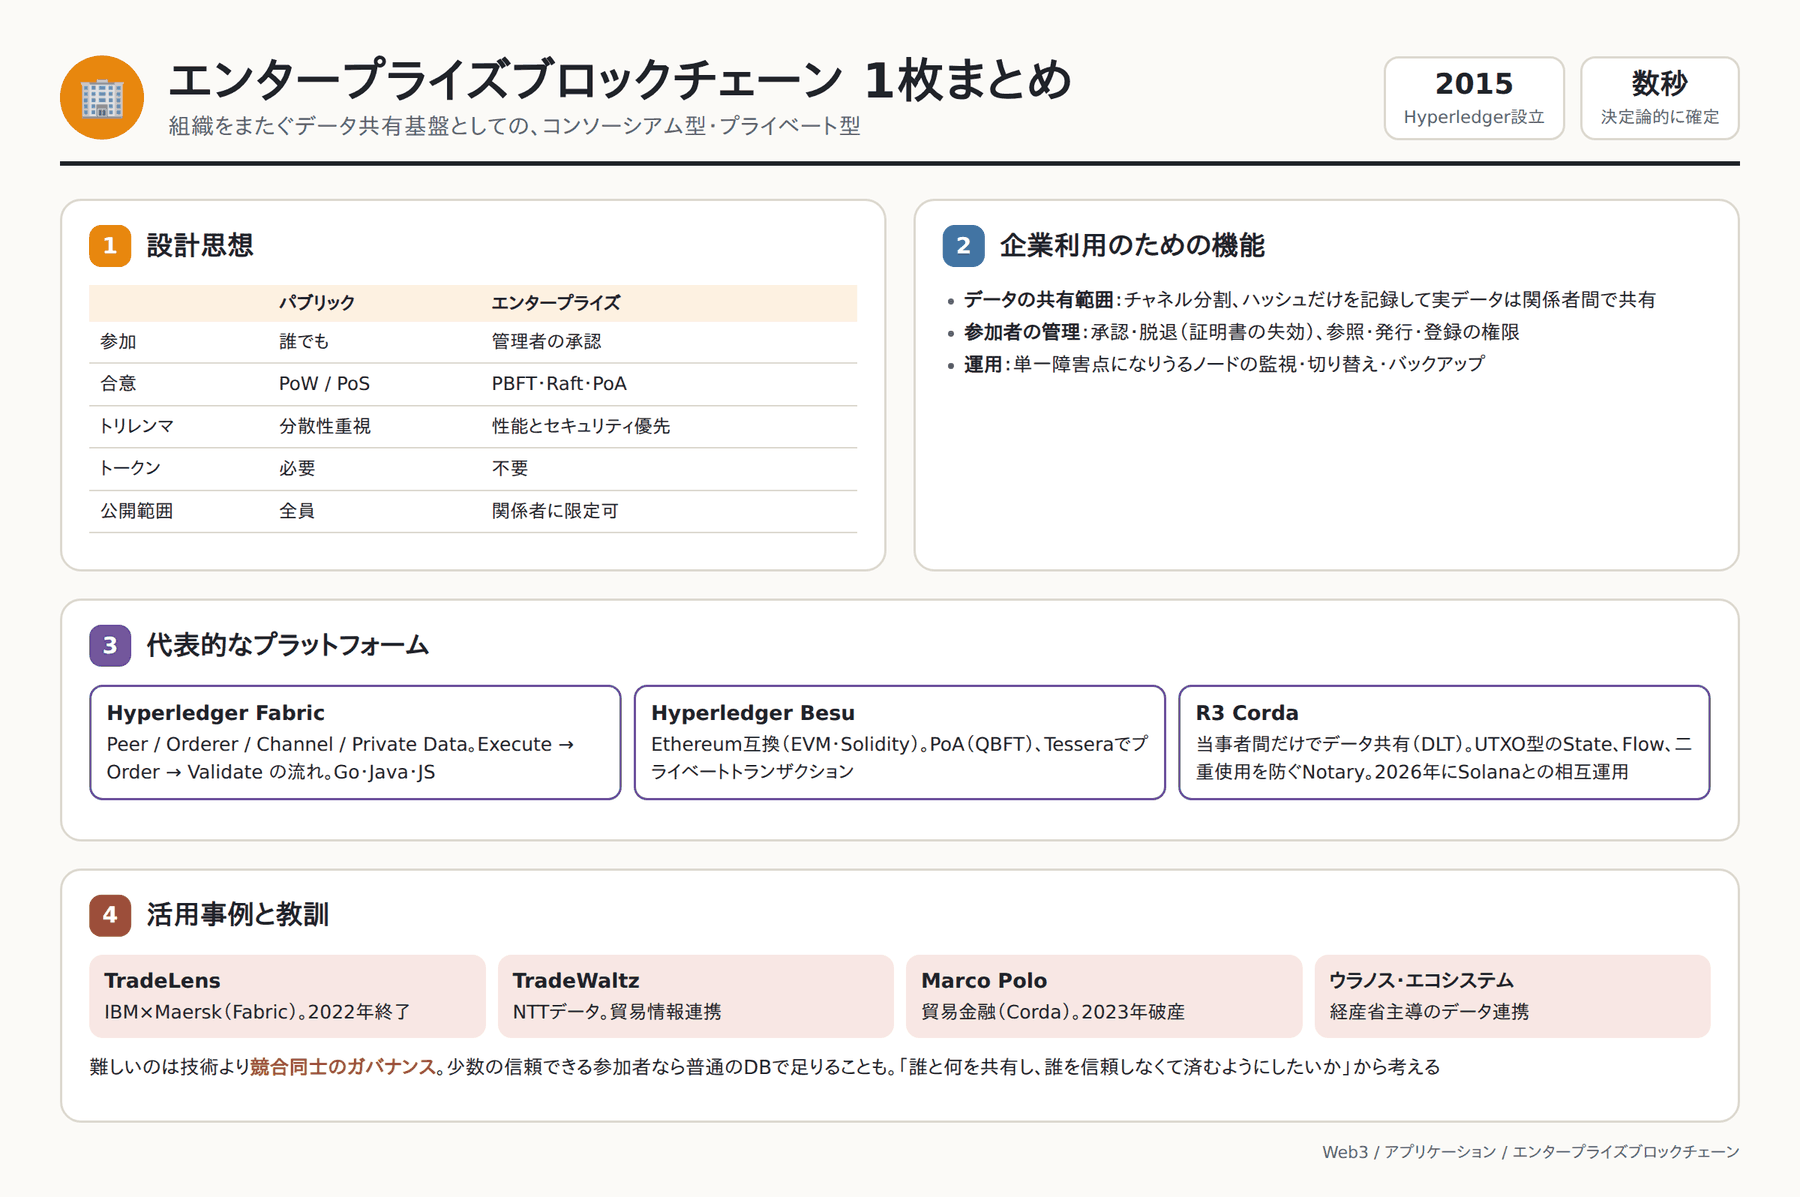

## エンタープライズブロックチェーンとは

明確な定義はないが、特定の企業や組織によって運営される **コンソーシアム型・プライベート型** のブロックチェーンを、エンタープライズブロックチェーンと呼ぶことが多い（→[ブロックチェーンの種類](../blockchain/index.ipynb)）。

### 背景

企業がブロックチェーンを使いたい動機は、**組織をまたいだデータ共有基盤** としての利用にある。複数の企業がそれぞれ自社のシステムで記録を持ち、照合に手間がかかっている業務（貿易書類、サプライチェーンの追跡、銀行間の決済など）で、改ざんが検知でき、全員が同じ記録を持てる共有台帳は魅力的に見える。

しかし、BitcoinやEthereumのようなパブリックチェーンでは、

- 取引内容が競合他社や一般の人にまで公開されてしまう
- 処理性能が低く、手数料の変動が大きい
- 各国の法律・規制（個人情報保護、金融規制）に沿った運用が難しい

ため、企業利用を想定した独自のブロックチェーンが開発されてきた。

### 歴史

- 2015年頃から、Ethereumとほぼ同時期に、複数の企業が独自のブロックチェーンの開発を始める
- 2015年12月、Linux Foundation傘下に **Hyperledger** が設立される（2024年に **LF Decentralized Trust** に改称）
- 2017年以降、金融・貿易・製造業などで多数の実証実験（PoC）が行われ、一部が商用化される

## 設計思想

### ブロックチェーンの定義を振り返る

日本ブロックチェーン協会（JBA）は、ブロックチェーンを2段階で定義している。

1. ビザンチン障害を含む不特定多数のノードを用い、時間の経過とともにその時点の合意が覆る確率が0へ収束するプロトコル、またはその実装（狭義）
2. 電子署名とハッシュポインタを使用し改ざん検出が容易なデータ構造を持ち、かつ当該データをネットワーク上に分散する多数のノードに保持させることで、高可用性及びデータ同一性等を実現する技術（広義）

エンタープライズブロックチェーンは主に2の意味でのブロックチェーンであり、パブリックチェーンで一般的なトークンやウォレットは、技術的には必須の要素ではない。

### パブリックチェーンとの違い

| 観点 | パブリックチェーン | エンタープライズブロックチェーン |
| --- | --- | --- |
| 参加 | 誰でも | 管理者の承認が必要（パーミッション型） |
| 参加者の前提 | 匿名、悪意がありうる | 身元の分かる組織。契約で縛られている |
| 合意形成 | PoW, PoS | PBFT系, Raft, PoA（Proof of Authority） |
| ファイナリティ | 確率的、または十数分 | ブロックに取り込まれた時点で確定（決定論的）。数秒 |
| トリレンマ | 分散性を重視 | 分散性を割り切り、スケーラビリティとセキュリティを優先 |
| ネイティブトークン | あり（手数料、インセンティブ） | 不要（参加者は信頼されており、インセンティブの仕組みが要らない） |
| データの公開範囲 | 全員に公開 | 参加者の中でも、関係者だけに限定できる |

### 企業利用のための機能

- **データの共有範囲の設定**：チェーン（チャネル）を分ける、チェーン上にはハッシュだけを記録して実データは関係者間でのみ共有する、などの方法で、参加者の中でも見せる相手を限定する
- **参加者の管理**：参加の承認・脱退（証明書の失効）、データの参照・トランザクションの発行・コントラクトの登録などの権限の設定
- **運用のサポート**：管理者機能やブロック生成を担うノードは単一障害点になりうるため、ノードの監視、障害時の切り替え、データのバックアップ

## 代表的なプラットフォーム

### Hyperledger Fabric

IBMが開発してHyperledgerに寄贈した、エンタープライズブロックチェーンの代表格。商用システムでの稼働実績が多い。

| 要素 | 内容 |
| --- | --- |
| Chaincode | スマートコントラクトに相当。Go, Java, JavaScriptで書く（Solidityは使えない） |
| Ledger | トランザクションの記録（ブロックチェーン）と、現在の状態（World State）の組 |
| Peer | Chaincodeと台帳を持ち、トランザクションを検証・実行する |
| Orderer | トランザクションを順序付けてブロックを作り、Peerに配る |
| Channel | 参加者のサブグループごとに別の台帳を持つ仕組み。同じネットワーク内でもデータの共有先を分けられる |
| Private Data | チャネル内のさらに一部の参加者だけで共有するデータ。台帳にはハッシュだけが記録される |
| MSP（Membership Service Provider） | 認証局の証明書に基づいて、各組織・ユーザーの権限を管理する |

Fabricのトランザクションは **Execute-Order-Validate** という独特の流れで処理される。

```mermaid
sequenceDiagram
    participant C as クライアント
    participant E as Endorsing Peer
    participant O as Ordering Service
    participant P as 全Peer
    C->>E: トランザクションの提案
    E->>E: Chaincodeを実行（台帳はまだ更新しない）
    E->>C: 実行結果に署名（Endorsement）して返す
    C->>O: 必要な数のEndorsementが揃ったら送信
    O->>O: 順序付けてブロックを作る
    O->>P: ブロックを配信
    P->>P: Endorsementポリシーと競合を検証して台帳に反映
```

先に実行してから順序付けるため、互いに関係のないトランザクションを並列に実行できる。


### Hyperledger Besu

https://github.com/besu-eth/besu

Consensysが開発してHyperledgerに寄贈した、Ethereum互換のクライアント。パブリックなEthereumのクライアントとしても使われるが、プライベートネットワーク向けの機能を持つ。

- EVMとSolidity、MetaMaskなどEthereumの開発ツールをそのまま使える
- 合意形成には **PoA（Proof of Authority）**（QBFT, IBFT 2.0, Clique）を使う。承認されたノードだけがブロックを作り、高速で決定論的なファイナリティを持つ
- **プライベートトランザクション**：Tesseraというトランザクションマネージャーを通じて、指定した相手（Privacy Group）にだけ内容を送り、チェーン上にはその参照キーだけを含むトランザクションを記録する



### R3 Corda

金融機関によるブロックチェーンの研究のために設立された[R3社](https://r3.com/)が開発したプラットフォーム。金融機関の要求に応えるため、参加者の身元と取引のプライバシーを特に重視している。

- **取引の当事者間でのみデータを共有する**。トランザクションはネットワーク全体に配信されず、自分に関係のないデータは持たない
- チェーンが1本にまとまらないため、ブロックチェーンではなく **分散台帳技術（DLT）** と呼ばれることが多い
- **State**：データの入れ物。上書きはできず、変化すると新しいStateが作られる（BitcoinのようなUTXOモデル）
- **Flow**：取引データの作成・署名・相手への送信・署名の要求といった、企業間取引の多段階のワークフローを自動化する仕組み
- **Notary**：トランザクションが全体に配信されないため、同じStateが別々のトランザクションで二重に消費されないことを保証する役割。トランザクションの中身は見ず、二重使用だけをチェックする
- Java, Kotlinでコントラクトを書く

:::{tip}

2026年2月には、R3がパブリックチェーンのSolana上で、トークン化した社債や不動産ローンなどのRWAの利回りを提供する「Corda Protocol」を展開すると発表した。既存のCordaネットワークとSolanaを相互運用させる構想で、エンタープライズチェーンとパブリックチェーンの接続の例といえる（参考：[SBI VCトレード「Solana（ソラナ／SOL）の現状：R3 Cordaとの提携が示す、TradFiとDeFiをつなぐハイブリッド構造」](https://www.sbivc.co.jp/columns/content/89izso797)）。

:::{tip} Cordaの活用事例
SBI R3 Japanが運営する [Corda活用事例を知る（Corda Portal）](https://cordajapan.net/categories/corda-usecases) では、金融（証券のポストトレード処理、デジタル証券、CBDC）、貿易（L/C取引の電子化）、保険、サプライチェーンなど、Cordaの国内外の導入事例が日本語で紹介されている。
:::

:::

### Enterprise Ethereum Alliance（EEA）

2017年に設立された、Ethereumの企業利用を推進する非営利団体。独自のプラットフォームは開発せず、標準やガイドラインの策定を行っている。

| | Hyperledger Fabric | Hyperledger Besu | R3 Corda |
| --- | --- | --- | --- |
| 開発元 | IBM → LF Decentralized Trust | Consensys → LF Decentralized Trust | R3 |
| データモデル | アカウント（World State） | アカウント（EVM） | UTXO（State） |
| データの共有範囲 | チャネル、Private Data | Privacy Group | 取引の当事者のみ |
| 合意形成 | Ordering Service（Raft等） | PoA（QBFT等） | Notary |
| 言語 | Go, Java, JavaScript | Solidity | Java, Kotlin |

## 活用事例

| 事例 | 分野 | 概要 | 基盤 |
| --- | --- | --- | --- |
| TradeLens | 貿易 | IBMと海運大手Maerskが開発した貿易書類のデジタル化プラットフォーム。最初の大規模な商用サービスとして注目されたが、業界全体の参加を得られず2022年にサービス終了 | Fabric |
| TradeWaltz | 貿易 | NTTデータが開発した貿易情報の連携基盤。日本の商社・海運会社などが参加 | Fabric |
| Marco Polo | 貿易金融 | 船荷証券などをデジタル化し、輸出企業が貨物の到着を待たずに資金を調達できるようにする。2023年に運営会社が破産 | Corda |
| ウラノス・エコシステム | データ連携 | 経済産業省が主導する、企業・業界・国境をまたぐデータ連携の取り組み。自動車・蓄電池のカーボンフットプリントなど。ブロックチェーンは要素技術の1つ | — |
| デジタル証券（セキュリティトークン） | 金融 | 社債や不動産受益権をトークン化して発行・流通させる | Progmat, ibet など |

### 教訓

多くのプロジェクトが実証実験で終わったり、商用化後に撤退したりしている。その理由として、

- 技術よりも、競合する企業同士が同じ基盤に参加する **ガバナンス** の合意が難しい（誰が運営し、誰が費用を負担し、誰がデータの恩恵を受けるか）
- 少数の信頼できる参加者で運営するなら、普通のデータベースやAPI連携で十分なことが多い
- 参加者が少ないと、ネットワーク効果が働かない

ことが指摘されている。「ブロックチェーンを使うこと」ではなく、「誰と何を共有し、誰を信頼しなくて済むようにしたいのか」から考えることが重要である。

一方で近年は、トークン化した預金や証券の決済、ステーブルコインの発行など、パブリックチェーンとの接続（相互運用性）を前提にした企業利用も増えている。

## 参考文献

- [Hyperledger Fabric Documentation](https://hyperledger-fabric.readthedocs.io/)
- [Hyperledger Besu Documentation](https://docs.besu-eth.org/)
- [R3 Corda Documentation](https://docs.r3.com/)
- Androulaki, E. et al. (2018). [Hyperledger Fabric: A Distributed Operating System for Permissioned Blockchains](https://arxiv.org/abs/1801.10228). EuroSys.
- [日本ブロックチェーン協会「ブロックチェーンの定義」](https://jba-web.jp/archives/2011003blockchain_definition)